# Imports

In [2]:
# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mpl_toolkits
from mpl_toolkits.mplot3d import Axes3D  # noqa
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import re

import sys, os
from pathlib import Path

# 1) where we are right now
CWD = Path.cwd()  # /Users/.../Systematic_Energy_Trading/futures_strategies

# 2) project root = parent of current folder
PROJECT_ROOT = CWD.parent  # /Users/.../Systematic_Energy_Trading

# 3) put *project root* at the very front of sys.path
sys.path.insert(0, str(PROJECT_ROOT))

# 4) quick check
print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("rolling.py exists?:", (PROJECT_ROOT / "energy/strategies/rolling.py").exists())



from energy.strategies.rolling import (
    rolling_pnl,
    roll_EL,
    RollingStrategy,
    roll_EOM_NGL,
    roll_EOM_EOM_expiry,
    roll_EOM_midmonth_expiry,
    roll_EOM_dynamic_brent,
)
from energy.strategies.momentum import (
    momentum
)

from energy.strategies.value import (
    value,
    statistical_arbitrage,
    carry_value,
    momentum_with_value_filter
)

from energy.strategies.portfolios import (
    equal_weight_static, risk_parity_static, risk_parity_dynamic, mvo
)
from energy.strategies.carry import carry
from energy.analytics.metrics import metrics
from energy.preprocess.expiry_calendar import expiry_calendar
from energy.preprocess.read_data import read_data
from energy.preprocess.drop_dupes import drop_dupes

plt.style.use("seaborn-v0_8-whitegrid")

data_path = "../data/Commods.xlsx"
calendar_path = "../data/expiry_calendars.xlsx"

CWD: /Users/markbogorad/Desktop/Quant_Projects/Systematic_Energy_Trading/futures_strategies
PROJECT_ROOT: /Users/markbogorad/Desktop/Quant_Projects/Systematic_Energy_Trading
rolling.py exists?: True


# Set Commodities

In [3]:
# roughly set to 0.01%-0.05%

# COMMODITIES = {
#     "Propane": ("BAP", 100, 1000, 0.001),
#     "Ethane":  ("CAP", 100, 1000, 0.001),
#     "Butane":  ("DAE", 100, 1000, 0.001),
#     "WTI":     ("CL", 100, 1000, 0.01),
#     "Brent":   ("CO", 100, 1000, 0.01),
#     "ULSD":    ("HO", 100, 1000, 0.05),
#     "RBOB":    ("XB", 100, 1000, 0.02),
#     "Gasoil":  ("QS", 100, 1000, 0.02), 
#     "Natgas":  ("NG", 100, 1000, 0.001), 
# }

# No t-cost

# COMMODITIES = {
#     "Propane": ("BAP", 100, 1000, 0),
#     "Ethane":  ("CAP", 100, 1000, 0),
#     "Butane":  ("DAE", 100, 1000, 0),
#     "WTI":     ("CL", 100, 1000, 0),
#     "Brent":   ("CO", 100, 1000, 0),
#     "ULSD":    ("HO", 100, 1000, 0),
#     "RBOB":    ("XB", 100, 1000, 0),
#     "Gasoil":  ("QS", 100, 1000, 0), 
#     "Natgas":  ("NG", 100, 1000, 0), 
# }

COMMODITIES = {
    "Propane": ("BAP", 100, 1000, 0),
    "Ethane":  ("CAP", 100, 1000, 0),
    "Butane":  ("DAE", 100, 1000, 0),
    "WTI":     ("CL", 100, 1000, 0),
    "Brent":   ("CO", 100, 1000, 0),
    "ULSD":    ("HO", 100, 1000, 0),
    "RBOB":    ("XB", 100, 1000, 0),
    "Gasoil":  ("QS", 100, 1000, 0), 
    "Natgas":  ("NG", 100, 1000, 0), 
    
    # "Murban":  ("MUC", 100, 1000, 0),
    # "Dubai":   ("DAT", 100, 1000, 0),
    # "WTI Houston": ("HRT", 100, 1000, 0),
    # "WTI Midland": ("HWT", 100, 1000, 0),
    # "Dutch TTF":   ("TSB", 100, 1000, 0), #720 MwH denominated in EUR.Mwh
    # "Fuel Oil":    ("AVR", 100, 1000, 0), # USD/BBL
    # "Gulf Jet Fuel": ("GF", 100, 1000, 0), # USD/gal (42K)
    # "Eurobob":     ("IHW", 100, 1000, 0), # USD/MT, 1K MT per contract
    # "Naphtha":  ("KI", 100, 1000, 0), # USD/MT, 1K MT per contract
    # "Japan Naphtha": ("JAA", 100, 1000, 0), # USD/MT, 1K MT per contract
}

NORMALIZATION = {
    # NGLs are quoted in ¢/gal  → $/bbl  = c/gal 100 * 0.42
    "Propane": 0.42*100,
    "Ethane":  0.42*100,
    "Butane":  0.42*100,

    # Refineds are quoted in $/gal → $/bbl = $/gal * 42, 
    # since already scaling by 100 per lot, the multiplier is 0.42
    "RBOB":   0.42,
    "ULSD":   0.42,
    "Gulf Jet Fuel": 0.42,

    # Crudes already in $/bbl
    "WTI":     1.0,
    "Brent":   1.0,

    # ICE Gasoil in $/metric ton → $/bbl ≈ $/ton / 7.45
    "Gasoil":  1.0 / 7.45,   # ≈ 0.134228
    "Eurobob": 1.0 / 7.45 * 10,
    "Naphtha": 1.0 / 7.45 * 10,
    "Japan Naphtha": 1.0 / 7.45 * 10,

    # Natgas in $/MMBtu → $/bbl-equiv ≈ $/MMBtu * 5.8
    "Natgas":  5.8,
}

roll_window = 5

CLEAN_DATA = {}
all_ma_results = {}
all_carry_results = {}

# Processing Functions

In [4]:
_FCOL_PATTERN = re.compile(r"^F\d+$")

def load_prices(commodity_name: str, ticker: str, *, normalize: bool = True) -> pd.DataFrame:
    sheet_name = f"{commodity_name} ({ticker})"
    df = read_data(data_path, sheet=sheet_name)
    df = drop_dupes(df).sort_index()

    if normalize:
        scale = NORMALIZATION.get(commodity_name, 1.0)
        if scale != 1.0:
            fcols = [c for c in df.columns if _FCOL_PATTERN.match(str(c))]
            if fcols:
                df.loc[:, fcols] = df[fcols] * scale
        # remember what we did
        df.attrs["norm_scale"] = scale
    else:
        df.attrs["norm_scale"] = 1.0

    return df


def load_expiry(ticker: str) -> pd.DatetimeIndex:
    return expiry_calendar(ticker, calendar_path)


# Rolling Futures (ALL)

Rolling Propane...


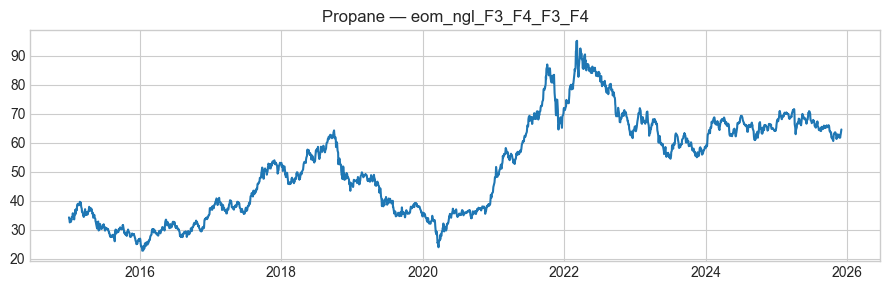

Rolling Ethane...


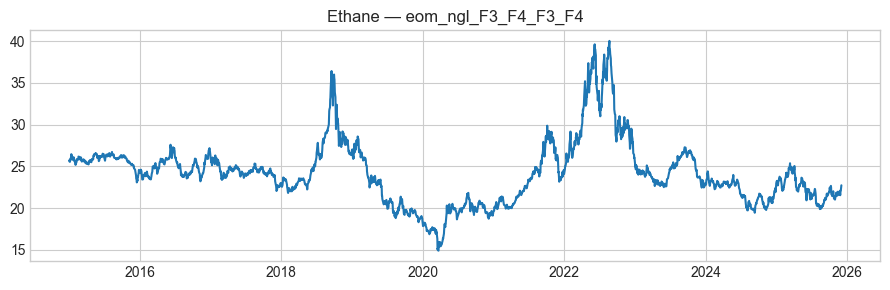

Rolling Butane...


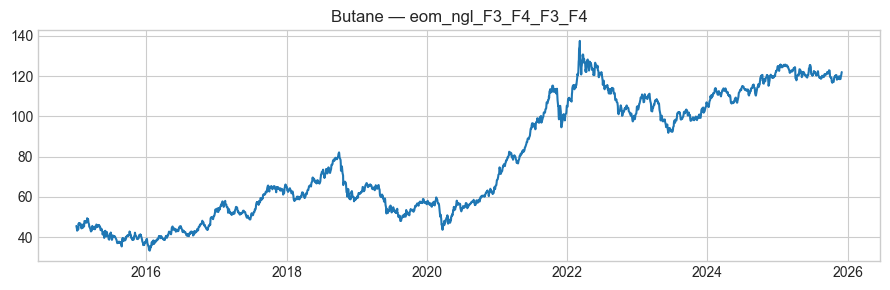

Rolling WTI...


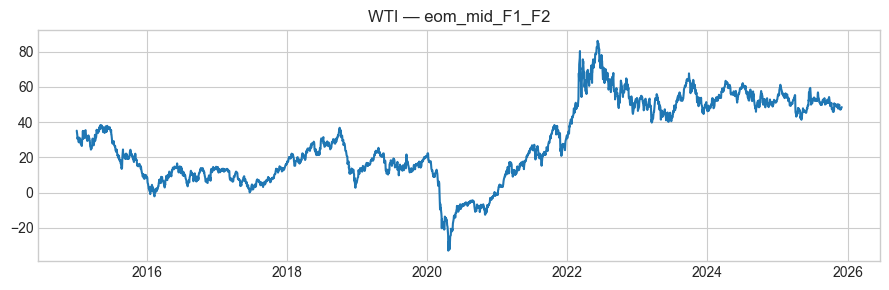

Rolling Brent...


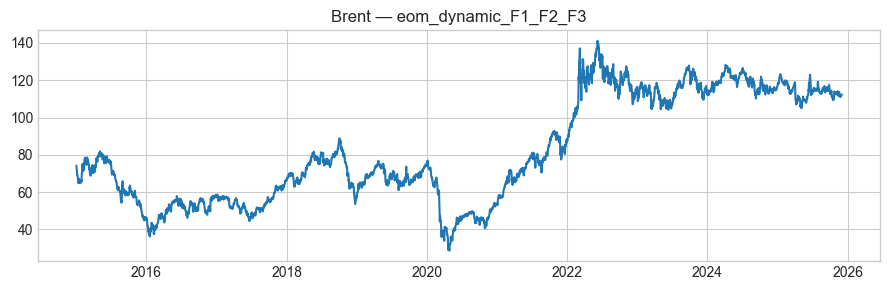

Rolling ULSD...


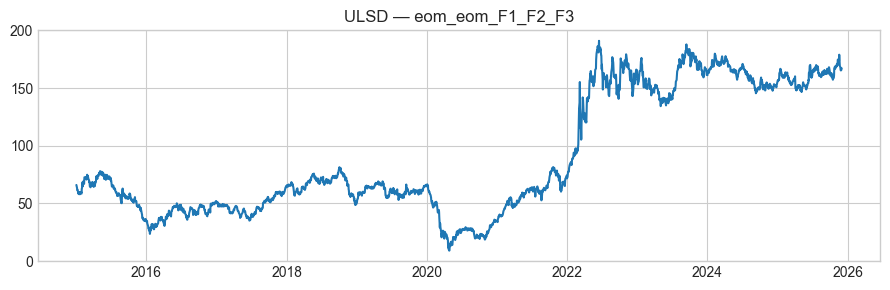

Rolling RBOB...


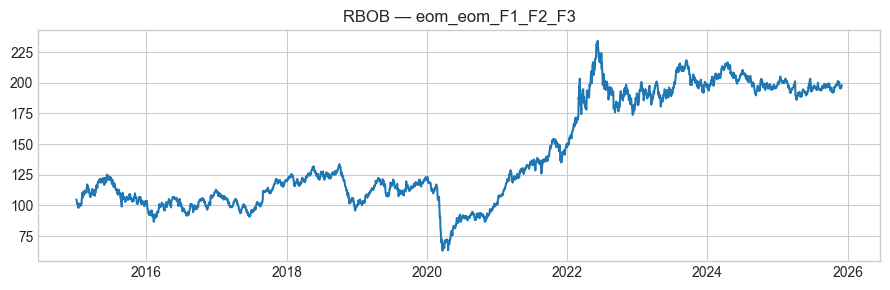

Rolling Gasoil...


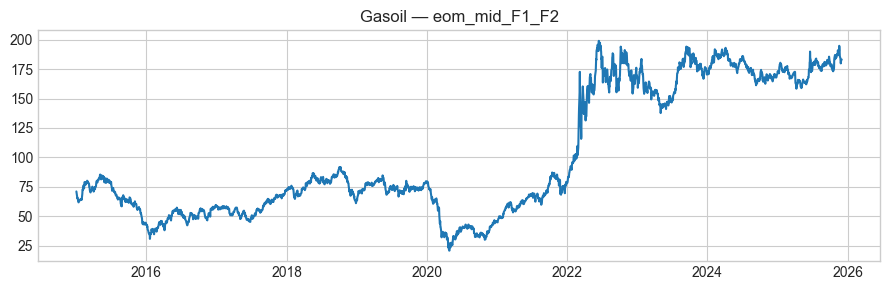

Rolling Natgas...


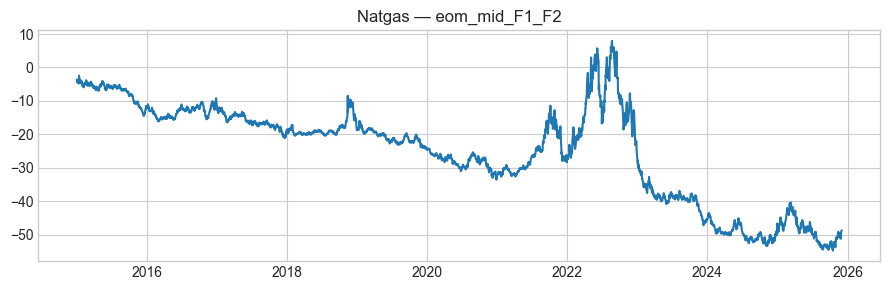

                                                       Total PnL  Total Cost  \
group             commodity roll_style                                         
Brent_dynamic     Brent     eom_dynamic_F1_F2_F3  3,728,000.0000     -0.0000   
NGL               Butane    eom_ngl_F3_F4_F3_F4   7,630,476.0000     -0.0000   
                  Ethane    eom_ngl_F3_F4_F3_F4    -286,902.0000     -0.0000   
                  Propane   eom_ngl_F3_F4_F3_F4   2,999,094.0000     -0.0000   
core_EOM_EOM      RBOB      eom_eom_F1_F2_F3      9,167,340.0000     -0.0000   
                  ULSD      eom_eom_F1_F2_F3      9,967,020.0000     -0.0000   
core_EOM_mid_F1F2 Gasoil    eom_mid_F1_F2        11,291,946.3087     -0.0000   
                  Natgas    eom_mid_F1_F2        -4,442,800.0000     -0.0000   
                  WTI       eom_mid_F1_F2         1,278,000.0000     -0.0000   

                                                  APL/unit (ann.)    CAGR  \
group             commodity roll_style    

In [5]:
HIST_START  = "2010-01-01"
TRADE_START = pd.Timestamp("2015-01-01")

BASE_ROLL_STYLES = {
    "Propane": {"style": "eom_ngl",     "front_col": "F3", "next_col": "F4", "mid_col": "F3", "far_col": "F4", "group": "NGL"},
    "Ethane":  {"style": "eom_ngl",     "front_col": "F3", "next_col": "F4", "mid_col": "F3", "far_col": "F4", "group": "NGL"},
    "Butane":  {"style": "eom_ngl",     "front_col": "F3", "next_col": "F4", "mid_col": "F3", "far_col": "F4", "group": "NGL"},

    "WTI":     {"style": "eom_mid",     "front_col": "F1", "next_col": "F2",                       "group": "core_EOM_mid_F1F2"},
    "Brent":   {"style": "eom_dynamic", "front_col": "F1", "next_col": "F2", "third_col": "F3",    "group": "Brent_dynamic"},
    "ULSD":    {"style": "eom_eom",     "front_col": "F1", "next_col": "F2", "third_col": "F3",    "group": "core_EOM_EOM"},
    "RBOB":    {"style": "eom_eom",     "front_col": "F1", "next_col": "F2", "third_col": "F3",    "group": "core_EOM_EOM"},
    "Gasoil":  {"style": "eom_mid",     "front_col": "F1", "next_col": "F2",                       "group": "core_EOM_mid_F1F2"},
    "Natgas":  {"style": "eom_mid",     "front_col": "F1", "next_col": "F2",                       "group": "core_EOM_mid_F1F2"},
}

def build_roll_cfg(commodity_name: str):
    base = BASE_ROLL_STYLES.get(commodity_name, {})
    style     = base.get("style", "eom_mid")
    front_col = base.get("front_col", "F1")
    next_col  = base.get("next_col",  "F2")
    mid_col   = base.get("mid_col")
    far_col   = base.get("far_col")
    third_col = base.get("third_col")
    group     = base.get("group", style)

    if "roll_style" in base:
        roll_style = base["roll_style"]
    else:
        parts = [style]
        if front_col: parts.append(front_col)
        if next_col:  parts.append(next_col)
        if mid_col:   parts.append(mid_col)
        if far_col:   parts.append(far_col)
        if third_col: parts.append(third_col)
        roll_style = "_".join(parts)

    return {
        "style": style,
        "front_col": front_col,
        "next_col": next_col,
        "mid_col": mid_col,
        "far_col": far_col,
        "third_col": third_col,
        "group": group,
        "roll_style": roll_style,
    }

ALL_LONG_ROLL     = {}
ALL_LONG_METRICS  = []
metrics_rows      = []

for commodity_name, (ticker, contracts, units, t_cost) in COMMODITIES.items():
    print(f"Rolling {commodity_name}...")

    prices = load_prices(commodity_name, ticker)
    expiry_cal = load_expiry(ticker)
    prices = prices[prices.index >= HIST_START]

    cfg = build_roll_cfg(commodity_name)

    rs = RollingStrategy(
        prices=prices,
        expiry_calendar=expiry_cal,
        front_col=cfg["front_col"],
        next_col=cfg["next_col"],
    )

    if cfg["style"] == "eom_ngl":
        equity_df = rs.equity(style="eom_ngl", t_cost=t_cost, mid_col=cfg["mid_col"], far_col=cfg["far_col"])
    elif cfg["style"] == "eom_mid":
        equity_df = rs.equity(style="eom_mid", t_cost=t_cost)
    elif cfg["style"] == "eom_dynamic":
        equity_df = rs.equity(style="eom_dynamic", t_cost=t_cost, third_col=cfg["third_col"])
    elif cfg["style"] == "eom_eom":
        equity_df = rs.equity(style="eom_eom", t_cost=t_cost, third_col=cfg["third_col"])
    else:
        raise ValueError(f"Unknown style: {cfg['style']}")

    if equity_df.empty or "equity_line" not in equity_df.columns:
        print(f"  -> WARNING: {commodity_name} equity series missing/empty, skipping.")
        continue

    first_valid = equity_df["equity_line"].first_valid_index()
    if first_valid is None:
        print(f"  -> WARNING: {commodity_name} equity_line all NaN, skipping.")
        continue

    last_date = equity_df.index.max()
    if last_date >= TRADE_START:
        effective_start = max(TRADE_START, first_valid)
    else:
        effective_start = first_valid

    equity_df = equity_df[equity_df.index >= effective_start]

    if equity_df.empty:
        print(f"  -> WARNING: {commodity_name} empty after effective clipping, skipping.")
        continue

    ALL_LONG_ROLL[commodity_name] = equity_df.copy()

    plt.figure(figsize=(9, 3))
    plt.plot(equity_df.index, equity_df["equity_line"])
    plt.title(f"{commodity_name} — {cfg['roll_style']}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    m = metrics(equity_df, contracts=contracts, units=units)
    m["commodity"]  = commodity_name
    m["group"]      = cfg["group"]
    m["roll_style"] = cfg["roll_style"]

    metrics_rows.append(m)
    ALL_LONG_METRICS.append(m)

roll_metrics_df = (
    pd.DataFrame(metrics_rows)
      .set_index(["group", "commodity", "roll_style"])
      .sort_index()
)

print(roll_metrics_df.head(40))




Rolling horizon tests for Propane...
  -> Horizon T5_Front: roll_type=T5, F3/F4
  -> Horizon EOM_F3F4: roll_type=EOM, F3/F4
  -> Horizon EOM_F6F7: roll_type=EOM, F6/F7
  -> Horizon EOM_F9F10: roll_type=EOM, F9/F10
  -> Horizon EOM_F12F13: roll_type=EOM, F12/F13


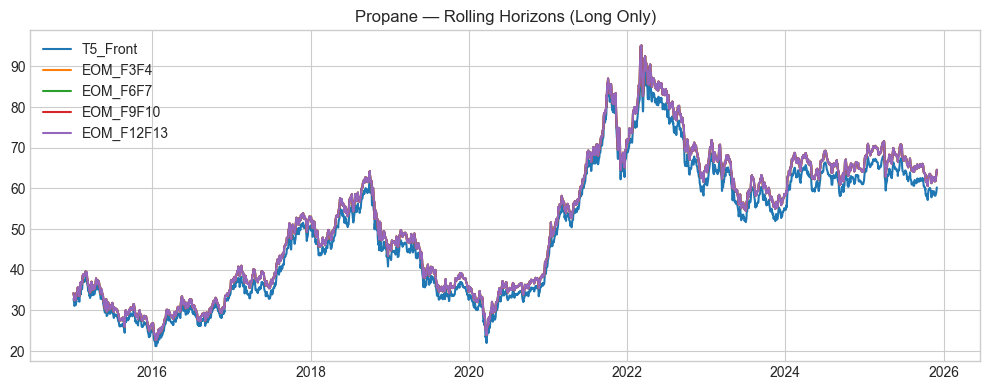


Rolling horizon tests for Ethane...
  -> Horizon T5_Front: roll_type=T5, F3/F4
  -> Horizon EOM_F3F4: roll_type=EOM, F3/F4
  -> Horizon EOM_F6F7: roll_type=EOM, F6/F7
  -> Horizon EOM_F9F10: roll_type=EOM, F9/F10
  -> Horizon EOM_F12F13: roll_type=EOM, F12/F13


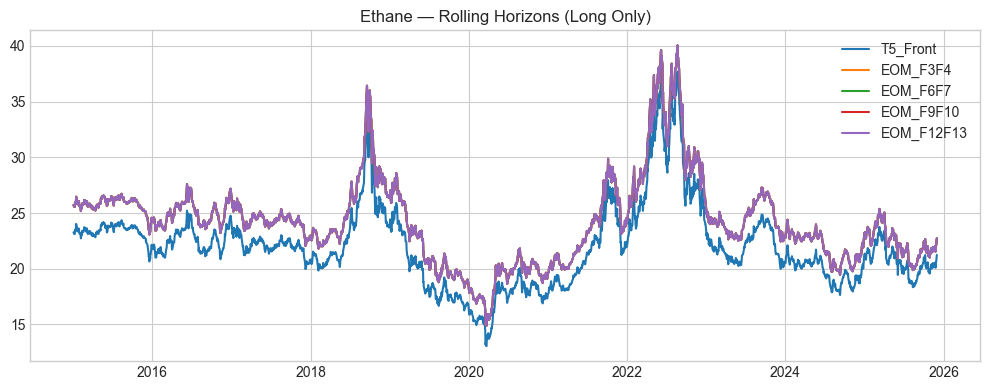


Rolling horizon tests for Butane...
  -> Horizon T5_Front: roll_type=T5, F3/F4
  -> Horizon EOM_F3F4: roll_type=EOM, F3/F4
  -> Horizon EOM_F6F7: roll_type=EOM, F6/F7
  -> Horizon EOM_F9F10: roll_type=EOM, F9/F10
  -> Horizon EOM_F12F13: roll_type=EOM, F12/F13


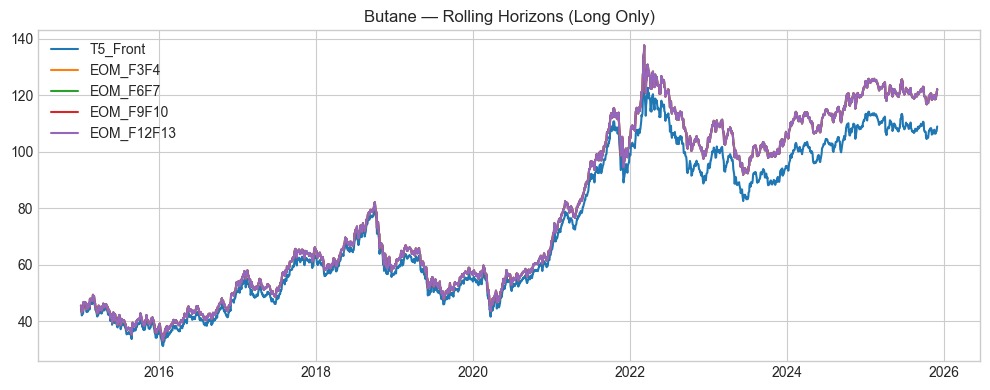


Rolling horizon tests for WTI...
  -> Horizon T5_Front: roll_type=T5, F1/F2
  -> Horizon EOM_F1F2: roll_type=EOM, F1/F2
  -> Horizon EOM_F3F4: roll_type=EOM, F3/F4
  -> Horizon EOM_F6F7: roll_type=EOM, F6/F7
  -> Horizon EOM_F9F10: roll_type=EOM, F9/F10
  -> Horizon EOM_F12F13: roll_type=EOM, F12/F13


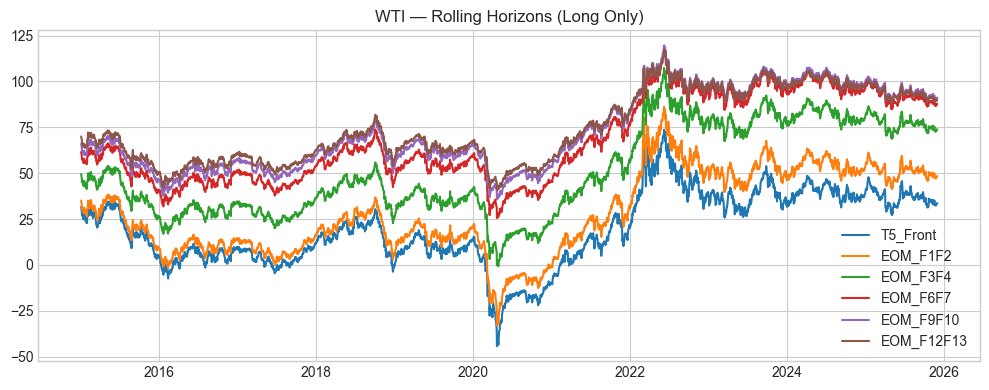


Rolling horizon tests for Brent...
  -> Horizon T5_Front: roll_type=T5, F1/F2
  -> Horizon EOM_F1F2: roll_type=EOM, F1/F2
  -> Horizon EOM_F3F4: roll_type=EOM, F3/F4
  -> Horizon EOM_F6F7: roll_type=EOM, F6/F7
  -> Horizon EOM_F9F10: roll_type=EOM, F9/F10
  -> Horizon EOM_F12F13: roll_type=EOM, F12/F13


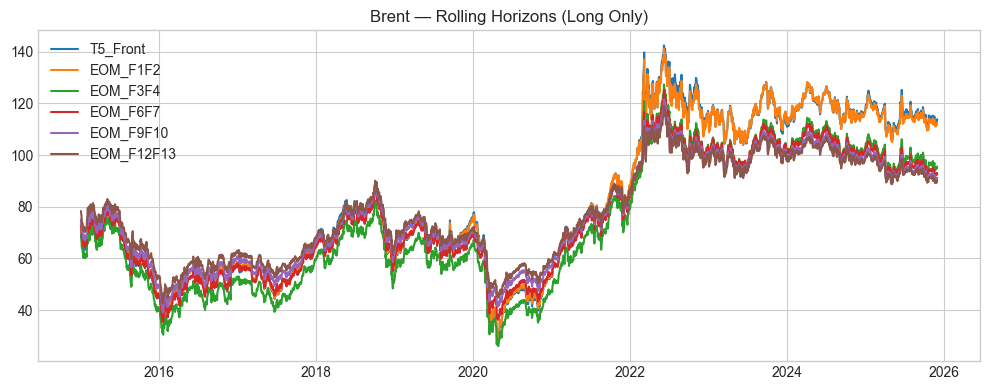


Rolling horizon tests for ULSD...
  -> Horizon T5_Front: roll_type=T5, F1/F2
  -> Horizon EOM_F1F2: roll_type=EOM, F1/F2
  -> Horizon EOM_F3F4: roll_type=EOM, F3/F4
  -> Horizon EOM_F6F7: roll_type=EOM, F6/F7
  -> Horizon EOM_F9F10: roll_type=EOM, F9/F10
  -> Horizon EOM_F12F13: roll_type=EOM, F12/F13


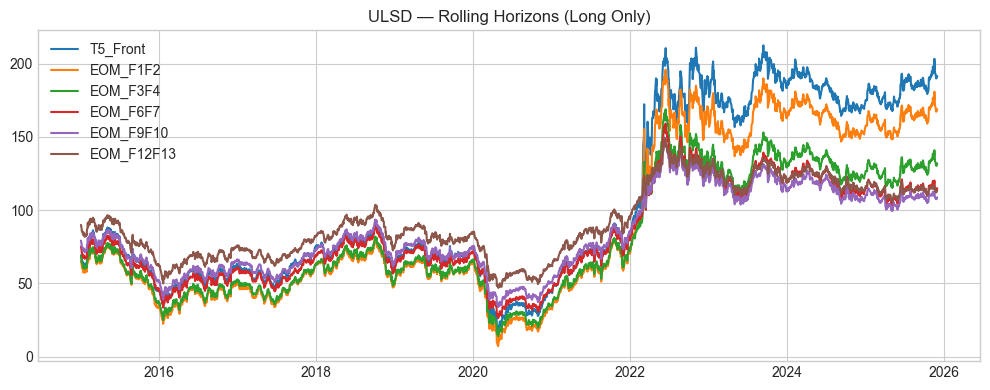


Rolling horizon tests for RBOB...
  -> Horizon T5_Front: roll_type=T5, F1/F2
  -> Horizon EOM_F1F2: roll_type=EOM, F1/F2
  -> Horizon EOM_F3F4: roll_type=EOM, F3/F4
  -> Horizon EOM_F6F7: roll_type=EOM, F6/F7
  -> Horizon EOM_F9F10: roll_type=EOM, F9/F10
  -> Horizon EOM_F12F13: roll_type=EOM, F12/F13


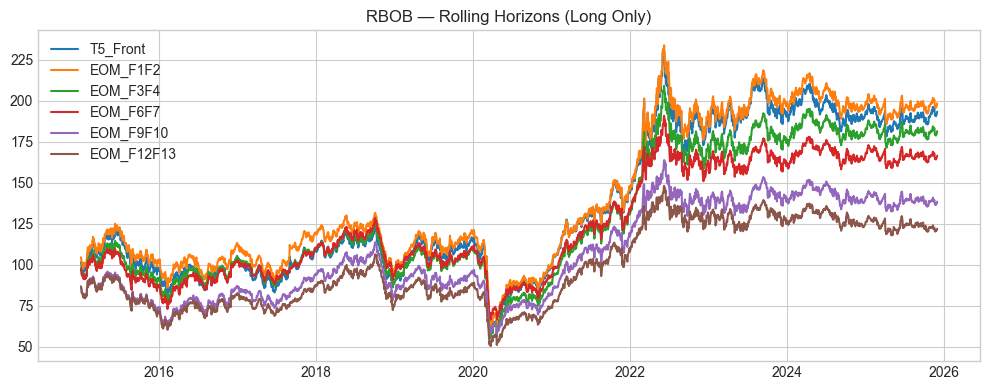


Rolling horizon tests for Gasoil...
  -> Horizon T5_Front: roll_type=T5, F1/F2
  -> Horizon EOM_F1F2: roll_type=EOM, F1/F2
  -> Horizon EOM_F3F4: roll_type=EOM, F3/F4
  -> Horizon EOM_F6F7: roll_type=EOM, F6/F7
  -> Horizon EOM_F9F10: roll_type=EOM, F9/F10
  -> Horizon EOM_F12F13: roll_type=EOM, F12/F13


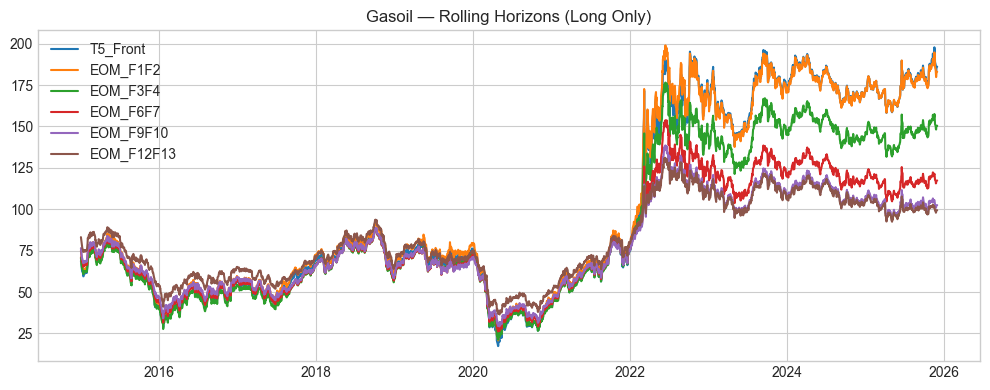


Rolling horizon tests for Natgas...
  -> Horizon T5_Front: roll_type=T5, F1/F2
  -> Horizon EOM_F1F2: roll_type=EOM, F1/F2
  -> Horizon EOM_F3F4: roll_type=EOM, F3/F4
  -> Horizon EOM_F6F7: roll_type=EOM, F6/F7
  -> Horizon EOM_F9F10: roll_type=EOM, F9/F10
  -> Horizon EOM_F12F13: roll_type=EOM, F12/F13


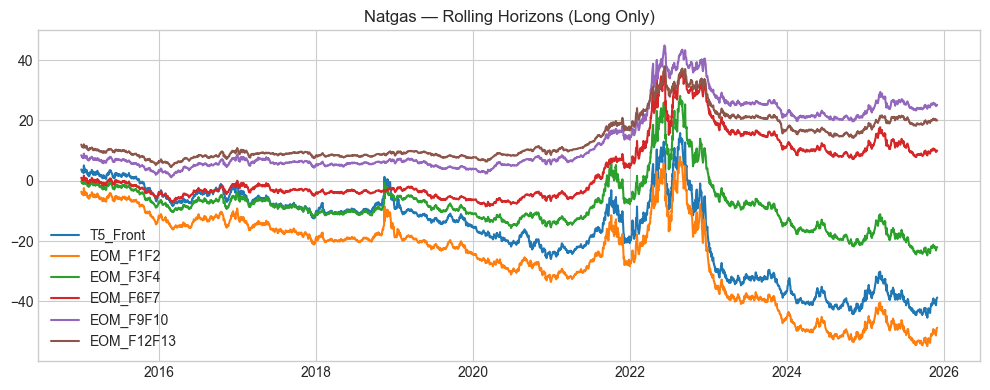

                                          roll_type front_col next_col  \
group             commodity horizon_label                                
Brent_dynamic     Brent     EOM_F12F13          EOM       F12      F13   
                            EOM_F1F2            EOM        F1       F2   
                            EOM_F3F4            EOM        F3       F4   
                            EOM_F6F7            EOM        F6       F7   
                            EOM_F9F10           EOM        F9      F10   
                            T5_Front             T5        F1       F2   
NGL               Butane    EOM_F12F13          EOM       F12      F13   
                            EOM_F3F4            EOM        F3       F4   
                            EOM_F6F7            EOM        F6       F7   
                            EOM_F9F10           EOM        F9      F10   
                            T5_Front             T5        F3       F4   
                  Ethane    EOM_F12F13

In [9]:
HIST_START   = "2010-01-01"
TRADE_START  = pd.Timestamp("2015-01-01")
TRADING_DAYS = 252
ROLL_WINDOW_T5 = 5  # T-5 days before expiry

BASE_ROLL_STYLES = {
    "Propane": {"style": "eom_ngl",     "front_col": "F3", "next_col": "F4", "mid_col": "F3", "far_col": "F4", "group": "NGL"},
    "Ethane":  {"style": "eom_ngl",     "front_col": "F3", "next_col": "F4", "mid_col": "F3", "far_col": "F4", "group": "NGL"},
    "Butane":  {"style": "eom_ngl",     "front_col": "F3", "next_col": "F4", "mid_col": "F3", "far_col": "F4", "group": "NGL"},

    "WTI":     {"style": "eom_mid",     "front_col": "F1", "next_col": "F2",                       "group": "core_EOM_mid_F1F2"},
    "Brent":   {"style": "eom_dynamic", "front_col": "F2", "next_col": "F3", "third_col": "F4",    "group": "Brent_dynamic"},
    "ULSD":    {"style": "eom_mid",     "front_col": "F1", "next_col": "F2", "third_col": "F3",    "group": "core_EOM_mid_F1F2"},
    "RBOB":    {"style": "eom_mid",     "front_col": "F1", "next_col": "F2", "third_col": "F3",    "group": "core_EOM_mid_F1F2"},
    "Gasoil":  {"style": "eom_mid",     "front_col": "F1", "next_col": "F2",                       "group": "core_EOM_mid_F1F2"},
    "Natgas":  {"style": "eom_mid",     "front_col": "F1", "next_col": "F2",                       "group": "core_EOM_mid_F1F2"},
}

def build_roll_cfg(commodity_name: str):
    base = BASE_ROLL_STYLES.get(commodity_name, {})
    style     = base.get("style", "eom_mid")
    front_col = base.get("front_col", "F1")
    next_col  = base.get("next_col",  "F2")
    mid_col   = base.get("mid_col")
    far_col   = base.get("far_col")
    third_col = base.get("third_col")
    group     = base.get("group", style)

    if "roll_style" in base:
        roll_style = base["roll_style"]
    else:
        parts = [style]
        if front_col: parts.append(front_col)
        if next_col:  parts.append(next_col)
        if mid_col:   parts.append(mid_col)
        if far_col:   parts.append(far_col)
        if third_col: parts.append(third_col)
        roll_style = "_".join(parts)

    return {
        "style": style,
        "front_col": front_col,
        "next_col": next_col,
        "mid_col": mid_col,
        "far_col": far_col,
        "third_col": third_col,
        "group": group,
        "roll_style": roll_style,
    }

def infer_third_col(front_col: str, next_col: str, default_third: str | None, prices: pd.DataFrame) -> str | None:
    """
    For eom_dynamic: try to infer third_col as the contract immediately after next_col (e.g. F1,F2 -> F3).
    Fall back to default_third if parsing fails or that column is missing.
    """
    try:
        # crude parsing for 'F<number>'
        n_next = int(next_col[1:])
        candidate = f"F{n_next + 1}"
        if candidate in prices.columns:
            return candidate
    except Exception:
        pass
    return default_third

# -------------------------------------------------------------------
# Long-only rolling horizon tests
# -------------------------------------------------------------------
ALL_LONG_ROLL    = {}   # (commodity, horizon_label) -> equity_df
ALL_LONG_METRICS = []
metrics_rows     = []

for commodity_name, (ticker, contracts, units, t_cost) in COMMODITIES.items():
    print(f"\nRolling horizon tests for {commodity_name}...")

    prices = load_prices(commodity_name, ticker)
    expiry_cal = load_expiry(ticker)
    prices = prices[prices.index >= HIST_START]

    if prices.empty:
        print(f"  -> No price data after {HIST_START}, skipping.")
        continue

    cfg_base = build_roll_cfg(commodity_name)

    # ---------------------------------------------------------
    # Curve shape: F1 - F13 (backwardation if +, contango if -)
    # ---------------------------------------------------------
    if {"F1", "F13"}.issubset(prices.columns):
        curve = prices[["F1", "F13"]].dropna()
        if not curve.empty:
            avg_F1_F13_spread = (curve["F1"] - curve["F13"]).mean()
            avg_F1_F13_spread_pct = ((curve["F1"] - curve["F13"]) / curve["F1"]).mean() * 100.0
        else:
            avg_F1_F13_spread = np.nan
            avg_F1_F13_spread_pct = np.nan
    else:
        avg_F1_F13_spread = np.nan
        avg_F1_F13_spread_pct = np.nan

    # ---------------------------------------------------------
    # Define tenor horizons by commodity type
    # ---------------------------------------------------------
    if commodity_name in ["Propane", "Ethane", "Butane"]:
        # NGLs: base "front" is M3/M4
        base_front = ("F3", "F4")
        tenor_pairs = [
            ("F3", "F4"),   # "front month" for NGLs
            ("F6", "F7"),
            ("F9", "F10"),
            ("F12", "F13"),
        ]
    else:
        base_front = ("F1", "F2")
        tenor_pairs = [
            ("F1", "F2"),   # front month
            ("F3", "F4"),   # M3/M4
            ("F6", "F7"),   # M6/M7
            ("F9", "F10"),  # M9/M10
            ("F12", "F13"), # M12/M13
        ]

    # -----------------------------
    # Horizon specs: T-5 + EOM
    # -----------------------------
    horizon_specs = []

    # T-5 on base front (F1/F2 or F3/F4)
    horizon_specs.append({
        "label":     "T5_Front",
        "roll_type": "T5",
        "front_col": base_front[0],
        "next_col":  base_front[1],
    })

    # EOM horizons
    for front_col, next_col in tenor_pairs:
        label = f"EOM_{front_col}{next_col}"
        horizon_specs.append({
            "label":     label,
            "roll_type": "EOM",
            "front_col": front_col,
            "next_col":  next_col,
        })

    # For plotting: collect all horizons' equity per commodity
    horizon_equity = {}  # label -> pd.Series(equity_line)

    # ---------------------------------------------------------
    # Run through each horizon choice
    # ---------------------------------------------------------
    for hspec in horizon_specs:
        label     = hspec["label"]
        roll_type = hspec["roll_type"]   # "T5" or "EOM"
        front_col = hspec["front_col"]
        next_col  = hspec["next_col"]

        # skip if the required tenor columns don't exist
        if front_col not in prices.columns or next_col not in prices.columns:
            print(f"  -> {label}: missing {front_col}/{next_col} columns, skipping.")
            continue

        print(f"  -> Horizon {label}: roll_type={roll_type}, {front_col}/{next_col}")

        # --------- T-5: OG rolling_pnl + roll_EL ----------
        if roll_type == "T5":
            res_t5 = rolling_pnl(
                prices=prices,
                expiry_calendar=expiry_cal,
                front_col=front_col,
                next_col=next_col,
                roll_window=ROLL_WINDOW_T5,
            )
            equity_df = roll_EL(res_t5, prices, front_col=front_col, t_cost=t_cost)

        # --------- EOM: RollingStrategy.equity ------------
        elif roll_type == "EOM":
            rs = RollingStrategy(
                prices=prices,
                expiry_calendar=expiry_cal,
                front_col=front_col,
                next_col=next_col,
            )
            style = cfg_base["style"]

            if style == "eom_ngl":
                equity_df = rs.equity(
                    style="eom_ngl",
                    t_cost=t_cost,
                    mid_col=cfg_base.get("mid_col"),
                    far_col=cfg_base.get("far_col"),
                )
            elif style == "eom_mid":
                equity_df = rs.equity(style="eom_mid", t_cost=t_cost)
            elif style == "eom_dynamic":
                # for Brent dynamic: third_col should be the contract after next_col (F2/F3 -> F4, F1/F2 -> F3, etc.)
                third_col = infer_third_col(
                    front_col=front_col,
                    next_col=next_col,
                    default_third=cfg_base.get("third_col"),
                    prices=prices,
                )
                equity_df = rs.equity(
                    style="eom_dynamic",
                    t_cost=t_cost,
                    third_col=third_col,
                )
            elif style == "eom_eom":
                equity_df = rs.equity(
                    style="eom_eom",
                    t_cost=t_cost,
                    third_col=cfg_base.get("third_col"),
                )
            else:
                raise ValueError(f"Unknown style: {style} for {commodity_name}, horizon {label}")
        else:
            raise ValueError(f"Unknown roll_type {roll_type} for {commodity_name}, horizon {label}")

        # -------------------------------------------------
        # Clean / clip equity series to TRADE_START
        # -------------------------------------------------
        if equity_df.empty or "equity_line" not in equity_df.columns:
            print(f"     -> WARNING: equity series missing/empty, skipping.")
            continue

        first_valid = equity_df["equity_line"].first_valid_index()
        if first_valid is None:
            print(f"     -> WARNING: equity_line all NaN, skipping.")
            continue

        last_date = equity_df.index.max()
        effective_start = max(TRADE_START, first_valid) if last_date >= TRADE_START else first_valid

        equity_df = equity_df[equity_df.index >= effective_start]
        if equity_df.empty:
            print(f"     -> WARNING: empty after effective clipping, skipping.")
            continue

        ALL_LONG_ROLL[(commodity_name, label)] = equity_df.copy()
        horizon_equity[label] = equity_df["equity_line"].copy()

        # -------------------------------------------------
        # PnL metrics: total PnL, std, info ratio
        # -------------------------------------------------
        pnl = equity_df["equity_line"].diff().dropna()

        if pnl.empty:
            total_pnl   = np.nan
            ann_pnl_std = np.nan
            info_ratio  = np.nan
        else:
            total_pnl   = equity_df["equity_line"].iloc[-1] - equity_df["equity_line"].iloc[0]
            daily_std   = pnl.std()
            ann_pnl_std = daily_std * np.sqrt(TRADING_DAYS)
            daily_mean  = pnl.mean()
            info_ratio  = (daily_mean / daily_std) * np.sqrt(TRADING_DAYS) if daily_std > 0 else np.nan

        m = {
            "commodity":              commodity_name,
            "group":                  cfg_base["group"],
            "horizon_label":          label,
            "roll_type":              roll_type,
            "front_col":              front_col,
            "next_col":               next_col,
            "total_pnl":              total_pnl,
            "ann_pnl_std":            ann_pnl_std,
            "info_ratio":             info_ratio,
            "avg_F1_F13_spread":      avg_F1_F13_spread,
            "avg_F1_F13_spread_pct":  avg_F1_F13_spread_pct,
        }

        metrics_rows.append(m)
        ALL_LONG_METRICS.append(m)

    # -------------------------------------------------
    # Plot ONE chart per commodity, all horizons
    # -------------------------------------------------
    if horizon_equity:
        plt.figure(figsize=(10, 4))
        for label, series in horizon_equity.items():
            plt.plot(series.index, series.values, label=label)
        plt.title(f"{commodity_name} — Rolling Horizons (Long Only)")
        plt.grid(True)
        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()

# -------------------------------------------------------------
# Build big metrics table and write to Excel
# -------------------------------------------------------------
roll_metrics_df = (
    pd.DataFrame(metrics_rows)
      .set_index(["group", "commodity", "horizon_label"])
      .sort_index()
)

print(roll_metrics_df.head(40))

roll_metrics_df.to_excel("rolling_horizon_long_only.xlsx", merge_cells=False)
print("Saved rolling_horizon_long_only.xlsx")


# PCT Contango vs Backwardation

In [ ]:
import re
import pandas as pd
import numpy as np

# -------------------------------------------------
# 1) Build CLEAN_DATA with F1–F30 curves
# -------------------------------------------------

_FCOL_PATTERN = re.compile(r"^F\d+$")  # you already have this above

def build_clean_data():
    """
    Populate CLEAN_DATA with normalized F1..F30 curves for each commodity.
    Keys will be the *commodity names* from COMMODITIES (e.g. 'WTI', 'Brent').
    """
    global CLEAN_DATA
    CLEAN_DATA = {}

    for com_name, (ticker, *_rest) in COMMODITIES.items():
        try:
            df_raw = load_prices(com_name, ticker, normalize=True)
        except Exception as e:
            print(f"[WARN] failed to load {com_name} ({ticker}): {e}")
            continue

        # Keep only F-columns (F1..F30) and drop all-NaN rows
        fcols = [c for c in df_raw.columns if _FCOL_PATTERN.match(str(c))]
        if not fcols:
            print(f"[WARN] no F-columns found for {com_name} ({ticker})")
            continue

        df_curve = df_raw[fcols].dropna(how="all").sort_index()

        if df_curve.empty:
            print(f"[WARN] curve empty after cleaning for {com_name} ({ticker})")
            continue

        CLEAN_DATA[com_name] = df_curve

    print("Built CLEAN_DATA with keys:", list(CLEAN_DATA.keys()))


import numpy as np
import pandas as pd

def curve_shape_slope_stats(curve_df: pd.DataFrame,
                            front_col: str = "F1",
                            far_col: str | None = None,
                            flat_tol: float = 1e-6) -> pd.Series:
    """
    Slope-based curve shape:

      F_front = F1
      F_far   = far_col (e.g. F30; if None -> max tenor in columns)

    contango day      : F_far - F_front > flat_tol
    backwardation day : F_far - F_front < -flat_tol
    flat day          : |F_far - F_front| <= flat_tol
    """
    # keep only F-columns
    f_cols = [c for c in curve_df.columns if str(c).startswith("F")]
    df = curve_df[f_cols].dropna(how="all")

    if front_col not in df.columns:
        raise ValueError(f"{front_col} not in columns: {df.columns.tolist()}")

    # pick far_col as the max tenor if not given
    if far_col is None:
        # sort like F1, F2, ..., F30
        f_sorted = sorted(f_cols, key=lambda x: int(str(x)[1:]))
        far_col = f_sorted[-1]

    if far_col not in df.columns:
        raise ValueError(f"{far_col} not in columns: {df.columns.tolist()}")

    front = df[front_col]
    far   = df[far_col]

    spread = far - front   # positive = contango, negative = backwardation

    contango_mask      = spread >  flat_tol
    backward_mask      = spread < -flat_tol
    flat_mask          = spread.abs() <= flat_tol

    n_obs = spread.notna().sum()

    return pd.Series(
        {
            "pct_contango": contango_mask.mean(),
            "pct_backwardation": backward_mask.mean(),
            "pct_flat": flat_mask.mean(),
            "n_obs": float(n_obs),
            "far_col_used": far_col,
        }
    )


# =====================================================
# Run slope-based stats for all commodities in CLEAN_DATA
# =====================================================

slope_shape_results = []

for com_name, df in CLEAN_DATA.items():
    stats = curve_shape_slope_stats(df, front_col="F1", far_col=None)  # far_col auto = max tenor
    stats["ticker"] = COMMODITIES[com_name][0]
    stats.name = com_name
    slope_shape_results.append(stats)

slope_shape_results = pd.DataFrame(slope_shape_results).sort_index()

print(slope_shape_results)



               pct_contango  pct_backwardation  pct_flat      n_obs  \
Brent                0.3185             0.6810    0.0005 4,110.0000   
Butane               0.2099             0.7901    0.0000 4,007.0000   
Dubai                0.1371             0.8629    0.0000 1,714.0000   
Dutch TTF            0.3072             0.6923    0.0005 1,999.0000   
Ethane               0.5999             0.4001    0.0000 4,001.0000   
Eurobob              0.2493             0.5050    0.0000 3,023.0000   
Fuel Oil             0.2839             0.7161    0.0000 2,705.0000   
Gasoil               0.3718             0.6280    0.0002 4,110.0000   
Gulf Jet Fuel        0.2677             0.4279    0.0000 2,237.0000   
Japan Naphtha        0.2095             0.5453    0.0000 3,023.0000   
Murban               0.0347             0.9653    0.0000 1,210.0000   
Naphtha              0.3892             0.5137    0.0000 3,619.0000   
Natgas               0.6519             0.3473    0.0007 4,008.0000   
Propan

# Run MOM, CAR, VAL Strategies and Report Split Metrics (each commodity)

In [ ]:
# =========================
# Global params: Value, Carry, MA
# =========================

INIT_CAPITAL = 10_000_000

HIST_START  = "2015-01-01"                  # build signals from here
TRADE_START = pd.Timestamp("2015-01-01")    # trading sample

# VALUE (on long roll M12/M13 where available)
VALUE_MA_WINDOW   = 252 * 5       # 5y mean
VALUE_VOL_WINDOW  = 252           # kept for signature compat (ignored in band)
VALUE_EPS_BAND    = 0.15          # 15% deviation band (relative to MA)

# CARRY (timespread F4–F15, no MA band logic at strategy level)
CARRY_FRONT_COL   = "F4"
CARRY_END_COL     = "F15"

# MA (short/med/long blended momentum)
MA_PAIRS          = [(1, 5), (5, 20), (10, 60)]
MA_WEIGHTS        = None  # equal weights inside momentum()

ALL_VALUE          = {}
ALL_VALUE_METRICS  = []

ALL_CARRY          = {}
ALL_CARRY_METRICS  = []

ALL_MA_MIX         = {}
ALL_MA_MIX_METRICS = []


# =========================
# Main loop over commodities
# =========================

for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES:
        raise KeyError(f"{commodity} missing in COMMODITIES.")

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    # --- load FULL history (normalized) ---
    prices_full = load_prices(commodity, ticker, normalize=True)
    prices_full = prices_full.loc[HIST_START:].sort_index()
    expiry_cal  = load_expiry(ticker)

    cols = prices_full.columns

    # =========================
    # BASE ROLL for CARRY & MA (per BASE_ROLL_STYLES)
    # =========================
    base_style     = cfg["style"]
    base_front_col = cfg.get("front_col", "F1")
    base_next_col  = cfg.get("next_col",  "F2")
    base_mid_col   = cfg.get("mid_col")
    base_third_col = cfg.get("third_col")

    rs_base = RollingStrategy(
        prices=prices_full,
        expiry_calendar=expiry_cal,
        front_col=base_front_col,
        next_col=base_next_col,
    )

    if base_style == "eom_ngl":
        rolled_base = rs_base.equity(style="eom_ngl", t_cost=t_cost,
                                     mid_col=base_mid_col, far_col=cfg.get("far_col"))
    elif base_style == "eom_mid":
        rolled_base = rs_base.equity(style="eom_mid", t_cost=t_cost)
    elif base_style == "eom_dynamic":
        rolled_base = rs_base.equity(style="eom_dynamic", t_cost=t_cost,
                                     third_col=base_third_col)
    elif base_style == "eom_eom":
        rolled_base = rs_base.equity(style="eom_eom", t_cost=t_cost,
                                     third_col=base_third_col)
    else:
        raise ValueError(f"Unknown base roll style: {base_style} for {commodity}")

    rolled_base = rolled_base.sort_index()

    for col in ["daily_pnl", "t_cost", "roll_day_flag"]:
        if col not in rolled_base.columns:
            raise ValueError(f"'{col}' missing in rolled_base for {commodity}")

    # =========================
    # LONG ROLL for VALUE (M12/M13 where possible)
    # =========================
    if "F12" in cols and "F13" in cols:
        roll_front_val = "F12"
        roll_next_val  = "F13"
        style_tag_val  = "M12-M13_EOM"
    elif "F12" in cols:
        roll_front_val = "F12"
        roll_next_val  = "F12"
        style_tag_val  = "F12_only_EOM"
    elif "F13" in cols:
        roll_front_val = "F13"
        roll_next_val  = "F13"
        style_tag_val  = "F13_only_EOM"
    else:
        roll_front_val = base_front_col
        roll_next_val  = base_next_col
        style_tag_val  = f"FALLBACK_{roll_front_val}_{roll_next_val}_EOM"

    rs_val = RollingStrategy(
        prices=prices_full,
        expiry_calendar=expiry_cal,
        front_col=roll_front_val,
        next_col=roll_next_val,
    )

    rolled_val = rs_val.equity(style="eom_mid", t_cost=t_cost).sort_index()

    for col in ["daily_pnl", "t_cost", "roll_day_flag"]:
        if col not in rolled_val.columns:
            raise ValueError(f"'{col}' missing in rolled_val for {commodity}")

    # =========================
    # VALUE STRATEGY
    # =========================

    if "F12" in cols:
        anchor_col = "F12"
    elif "F13" in cols:
        anchor_col = "F13"
    else:
        anchor_col = roll_front_val
        print(f"[WARN] {commodity}: using {anchor_col} as value anchor (no F12/F13).")

    prices_full["VAL_ANCHOR"] = prices_full[anchor_col].astype(float)

    val_full = value(
        prices=prices_full,
        rolled_df=rolled_val,
        front_col="VAL_ANCHOR",
        long_ma=VALUE_MA_WINDOW,
        vol_window=VALUE_VOL_WINDOW,
        epsilon_factor=VALUE_EPS_BAND,
        t_cost=t_cost,
    )

    val_df = val_full.loc[TRADE_START:].copy()
    if val_df.empty:
        print(f"[WARN] {commodity}: VALUE series empty after TRADE_START clipping, skipping VALUE.")
    else:
        exposure = contracts * units
        val_df["pnl_usd"]        = val_df["net_pnl"] * exposure
        val_df["cum_pnl_usd"]    = val_df["pnl_usd"].cumsum()
        val_df["equity_account"] = INIT_CAPITAL + val_df["cum_pnl_usd"]

        acc       = val_df["equity_account"]
        ret_ratio = acc / acc.shift(1)
        mask      = (acc > 0) & (acc.shift(1) > 0)

        val_df["log_ret"]           = np.nan
        val_df.loc[mask, "log_ret"] = np.log(ret_ratio[mask])
        val_df["cum_log_ret"]       = val_df["log_ret"].cumsum()
        val_df["log_equity_norm"]   = val_df["cum_log_ret"]
        val_df["equity_norm"]       = val_df["equity_account"] / INIT_CAPITAL

        val_df["commodity"]   = commodity
        val_df["ticker"]      = ticker
        val_df["style"]       = style_tag_val
        val_df["ma_window"]   = VALUE_MA_WINDOW
        val_df["vol_window"]  = VALUE_VOL_WINDOW
        val_df["eps_band"]    = VALUE_EPS_BAND

        ALL_VALUE[commodity] = val_df

        m = metrics(val_df, contracts=contracts, units=units)
        if isinstance(m, pd.Series):
            m = m.to_dict()
        m["commodity"]  = commodity
        m["style"]      = style_tag_val
        m["ma_window"]  = VALUE_MA_WINDOW
        m["vol_window"] = VALUE_VOL_WINDOW
        m["eps_band"]   = VALUE_EPS_BAND
        ALL_VALUE_METRICS.append(m)

    # =========================
    # CARRY STRATEGY (using BASE roll)
    # =========================

    if (CARRY_FRONT_COL in cols) and (CARRY_END_COL in cols):
        carry_full = carry_value(
            prices=prices_full,
            rolled_df=rolled_base,
            front_col=CARRY_FRONT_COL,
            end_col=CARRY_END_COL,
            t_cost=t_cost,
        )

        carry_df = carry_full.loc[TRADE_START:].copy()
        if carry_df.empty:
            print(f"[WARN] {commodity}: CARRY series empty after TRADE_START clipping, skipping CARRY.")
        else:
            exposure = contracts * units
            carry_df["pnl_usd"]        = carry_df["net_pnl"] * exposure
            carry_df["cum_pnl_usd"]    = carry_df["pnl_usd"].cumsum()
            carry_df["equity_account"] = INIT_CAPITAL + carry_df["cum_pnl_usd"]

            acc       = carry_df["equity_account"]
            ret_ratio = acc / acc.shift(1)
            mask      = (acc > 0) & (acc.shift(1) > 0)

            carry_df["log_ret"]           = np.nan
            carry_df.loc[mask, "log_ret"] = np.log(ret_ratio[mask])
            carry_df["cum_log_ret"]       = carry_df["log_ret"].cumsum()
            carry_df["log_equity_norm"]   = carry_df["cum_log_ret"]
            carry_df["equity_norm"]       = carry_df["equity_account"] / INIT_CAPITAL

            carry_df["commodity"]   = commodity
            carry_df["ticker"]      = ticker
            carry_df["style"]       = f"CARRY_{CARRY_FRONT_COL}_{CARRY_END_COL}"
            carry_df["front_col"]   = CARRY_FRONT_COL
            carry_df["end_col"]     = CARRY_END_COL

            ALL_CARRY[commodity] = carry_df

            m = metrics(carry_df, contracts=contracts, units=units)
            if isinstance(m, pd.Series):
                m = m.to_dict()
            m["commodity"]  = commodity
            m["style"]      = f"CARRY_{CARRY_FRONT_COL}_{CARRY_END_COL}"
            m["front_col"]  = CARRY_FRONT_COL
            m["end_col"]    = CARRY_END_COL
            ALL_CARRY_METRICS.append(m)
    else:
        print(f"[WARN] {commodity}: missing {CARRY_FRONT_COL}/{CARRY_END_COL}, skipping CARRY.")

    # =========================
    # MA (Momentum) STRATEGY (using BASE roll)
    # =========================

    ma_full = momentum(
        prices=prices_full,
        rolled_df=rolled_base,
        ma_pairs=MA_PAIRS,
        weights=MA_WEIGHTS,
        t_cost=t_cost,
    )

    ma_df = ma_full.loc[TRADE_START:].copy()
    if ma_df.empty:
        print(f"[WARN] {commodity}: MA series empty after TRADE_START clipping, skipping MA.")
    else:
        exposure = contracts * units
        ma_df["pnl_usd"]        = ma_df["net_pnl"] * exposure
        ma_df["cum_pnl_usd"]    = ma_df["pnl_usd"].cumsum()
        ma_df["equity_account"] = INIT_CAPITAL + ma_df["cum_pnl_usd"]

        acc       = ma_df["equity_account"]
        ret_ratio = acc / acc.shift(1)
        mask      = (acc > 0) & (acc.shift(1) > 0)

        ma_df["log_ret"]           = np.nan
        ma_df.loc[mask, "log_ret"] = np.log(ret_ratio[mask])
        ma_df["cum_log_ret"]       = ma_df["log_ret"].cumsum()
        ma_df["log_equity_norm"]   = ma_df["cum_log_ret"]
        ma_df["equity_norm"]       = ma_df["equity_account"] / INIT_CAPITAL

        ma_df["commodity"]   = commodity
        ma_df["ticker"]      = ticker
        ma_df["style"]       = "MA_blend"
        ma_df["ma_pairs"]    = str(MA_PAIRS)

        ALL_MA_MIX[commodity] = ma_df

        m = metrics(ma_df, contracts=contracts, units=units)
        if isinstance(m, pd.Series):
            m = m.to_dict()
        m["commodity"]  = commodity
        m["style"]      = "MA_blend"
        m["ma_pairs"]   = str(MA_PAIRS)
        ALL_MA_MIX_METRICS.append(m)

# =========================
# Metrics tables by commodity / strategy
# =========================

VALUE_METRICS = pd.DataFrame(ALL_VALUE_METRICS).set_index("commodity")
CARRY_METRICS = pd.DataFrame(ALL_CARRY_METRICS).set_index("commodity")
MA_METRICS    = pd.DataFrame(ALL_MA_MIX_METRICS).set_index("commodity")

print("VALUE_METRICS:")
print(VALUE_METRICS)

print("\nCARRY_METRICS:")
print(CARRY_METRICS)

print("\nMA_METRICS:")
print(MA_METRICS)

# =========================
# Metrics tables by commodity / strategy
# =========================

VALUE_METRICS = pd.DataFrame(ALL_VALUE_METRICS).set_index("commodity")
CARRY_METRICS = pd.DataFrame(ALL_CARRY_METRICS).set_index("commodity")
MA_METRICS    = pd.DataFrame(ALL_MA_MIX_METRICS).set_index("commodity")

print("VALUE_METRICS:")
print(VALUE_METRICS)

print("\nCARRY_METRICS:")
print(CARRY_METRICS)

print("\nMA_METRICS:")
print(MA_METRICS)


# =========================
# Build Standardized Metrics Panel
# =========================

# columns that are metadata / config (NOT performance metrics)
META_COLS = {
    "style", "ma_pairs", "ma_window", "vol_window", "eps_band",
    "front_col", "end_col", "ticker"
}

def strip_meta(df: pd.DataFrame) -> pd.DataFrame:
    """Drop non-performance columns so we don't get garbage rows in the panel."""
    return df[[c for c in df.columns if c not in META_COLS]]

# helper: slice a dict of equity DataFrames by date range and recompute metrics
def slice_by_period(df_dict, start, end):
    out = {}
    for com, df in df_dict.items():
        if "equity_account" not in df.columns:
            continue
        sliced = df.loc[start:end]
        if sliced.empty:
            continue
        m = metrics(sliced)
        if isinstance(m, pd.Series):
            m = m.to_dict()
        out[com] = m
    if not out:
        return pd.DataFrame()
    return pd.DataFrame(out).T  # commodities as rows

# ---------- FULL SAMPLE (use already-computed metrics, but strip meta) ----------
mom_full = strip_meta(MA_METRICS.copy())       # index: commodity, cols: perf metrics only
car_full = strip_meta(CARRY_METRICS.copy())
val_full = strip_meta(VALUE_METRICS.copy())

# ---------- SUB PERIODS ----------
PER1 = ("2015-01-01", "2022-01-01")
PER2 = ("2022-01-01", "2025-01-01")

mom_15_22 = strip_meta(slice_by_period(ALL_MA_MIX,  *PER1))
car_15_22 = strip_meta(slice_by_period(ALL_CARRY,   *PER1))
val_15_22 = strip_meta(slice_by_period(ALL_VALUE,   *PER1))

mom_22_25 = strip_meta(slice_by_period(ALL_MA_MIX,  *PER2))
car_22_25 = strip_meta(slice_by_period(ALL_CARRY,   *PER2))
val_22_25 = strip_meta(slice_by_period(ALL_VALUE,   *PER2))

# ---------- Long form helper ----------
def metrics_to_long(df, strategy, sample_label):
    """
    df: metrics DataFrame (index=commodity, columns=metric names)
    returns long-form DF with index (commodity, metric) and columns:
      ['value', 'Strategy', 'Sample']
    """
    if df.empty:
        return pd.DataFrame(
            columns=["value", "Strategy", "Sample"],
            index=pd.MultiIndex.from_arrays([[], []], names=["commodity", "metric"])
        )

    tmp = df.copy()
    tmp["commodity"] = tmp.index
    tmp = tmp.set_index("commodity")

    long = tmp.stack().to_frame("value")  # index: (commodity, metric)
    long.index.set_names(["commodity", "metric"], inplace=True)
    long["Strategy"] = strategy
    long["Sample"]   = sample_label
    return long

# ---------- Build long panel ----------
pieces = []

# Full sample
pieces.append(metrics_to_long(mom_full,   "MOM", "Full"))
pieces.append(metrics_to_long(car_full,   "CAR", "Full"))
pieces.append(metrics_to_long(val_full,   "VAL", "Full"))

# 2015–2022
pieces.append(metrics_to_long(mom_15_22,  "MOM", "2015-2022"))
pieces.append(metrics_to_long(car_15_22,  "CAR", "2015-2022"))
pieces.append(metrics_to_long(val_15_22,  "VAL", "2015-2022"))

# 2022–2025
pieces.append(metrics_to_long(mom_22_25,  "MOM", "2022-2025"))
pieces.append(metrics_to_long(car_22_25,  "CAR", "2022-2025"))
pieces.append(metrics_to_long(val_22_25,  "VAL", "2022-2025"))

long_panel = pd.concat(pieces, axis=0)

# =========================
# Assemble into Final Panel
# =========================

# index: (commodity, metric)
# columns: MultiIndex (Sample, Strategy)
panel_df = (
    long_panel
    .set_index(["Sample", "Strategy"], append=True)["value"]
    .unstack(["Sample", "Strategy"])
)

# Optional: order levels as [2015-2022, 2022-2025, Full] and [MOM, CAR, VAL]
panel_df = panel_df.reindex(
    columns=pd.MultiIndex.from_product(
        [["2015-2022", "2022-2025", "Full"], ["MOM", "CAR", "VAL"]],
        names=["Sample", "Strategy"],
    )
)

display(panel_df)


VALUE_METRICS:
               Total PnL  Total Cost  APL/unit (ann.)    CAGR  Std Dev (ann.)  \
commodity                                                                       
Propane    -852,936.0000     -0.0000          -0.7810 -0.0081          6.0767   
Ethane      184,170.0000     -0.0000           0.1686  0.0017          2.5420   
Butane     -783,762.0000     -0.0000          -0.7177 -0.0074          7.0251   
WTI         416,000.0000     -0.0000           0.3809  0.0037         12.6943   
Brent     1,576,000.0000     -0.0000           1.4432  0.0135         12.8399   
ULSD        553,980.0000     -0.0000           0.5073  0.0049         15.5908   
RBOB       -435,120.0000     -0.0000          -0.3984 -0.0041         15.5367   
Gasoil     -567,114.0940     -0.0000          -0.5193 -0.0053         15.3440   
Natgas     -624,660.0000     -0.0000          -0.5720 -0.0059          4.0949   

           Sharpe  Drawdown     RoD   Years        style  ma_window  \
commodity             

/Users/markbogorad/Desktop/Quant_Projects/Systematic_Energy_Trading/energy/analytics/metrics.py:31: RuntimeWarning: invalid value encountered in double_scalars
  cagr = (end_val / start_val) ** (1.0 / years) - 1.0


Sample                      2015-2022                             2022-2025  \
Strategy                          MOM          CAR         VAL          MOM   
commodity metric                                                              
Brent     APL/unit (ann.)      2.0143      -8.7329      1.3914     -15.1811   
          CAGR                 0.0190      -0.1263      0.0134      -0.1799   
          Drawdown            -0.3812      -0.6788     -0.1839      -0.6372   
          RoD                  5.2836     -12.8648      7.5668     -23.8263   
          Sharpe               0.1032      -0.4806      0.1409      -0.4728   
...                               ...          ...         ...          ...   
WTI       Sharpe               0.1370      -0.3244     -0.0462      -0.2645   
          Std Dev (ann.)      19.7817      18.5932      9.7426      32.7728   
          Total Cost          -0.0000      -0.0000     -0.0000      -0.0000   
          Total PnL       18,970.0000 -42,220.0000 -3,150.0000 -25,960.0000   
          Years                7.0000       7.0000      7.0000       2.9945   

Sample                                                    Full               \
Strategy                          CAR        VAL           MOM          CAR   
commodity metric                                                              
Brent     APL/unit (ann.)      0.6612     0.5811       -4.4952      -5.2305   
          CAGR                 0.0107     0.0099       -0.0599      -0.0746   
          Drawdown            -0.5387    -0.3329       -0.6937      -1.1529   
          RoD                  1.2275     1.7455       -6.4805      -4.5369   
          Sharpe               0.0206     0.0302       -0.1902      -0.2280   
...                               ...        ...           ...          ...   
WTI       Sharpe               0.4770     0.0305       -0.0199       0.0368   
          Std Dev (ann.)      32.7626    19.0610       24.0760      23.4627   
          Total Cost          -0.0000    -0.0000       -0.0000      -0.0000   
          Total PnL       46,800.0000 1,740.0000 -523,000.0000 942,000.0000   
          Years                2.9945     2.9945       10.9205      10.9205   

Sample                                  
Strategy                           VAL  
commodity metric                        
Brent     APL/unit (ann.)       1.4432  
          CAGR                  0.0135  
          Drawdown             -0.3270  
          RoD                   4.4131  
          Sharpe                0.1124  
...                                ...  
WTI       Sharpe                0.0300  
          Std Dev (ann.)       12.6943  
          Total Cost           -0.0000  
          Total PnL       416,000.0000  
          Years                10.9205  

[81 rows x 9 columns]

# Run MOM, CAR, VAL Strategies and Report Split Metrics (portfolio)

Rolling Propane...
Rolling Ethane...
Rolling Butane...
Rolling WTI...
Rolling Brent...
Rolling ULSD...
Rolling RBOB...
Rolling Gasoil...
Rolling Natgas...
Running strategies for WTI...
Running strategies for Brent...
Running strategies for ULSD...
Running strategies for RBOB...
Running strategies for Gasoil...
Running strategies for Natgas...
Running strategies for Propane...
Running strategies for Butane...
Running strategies for Ethane...


Sample              Full                2015-2022                2022-2025  \
Strategy             MOM    CAR     VAL       MOM    CAR     VAL       MOM   
commodity metric                                                             
WTI       Return -0.0095 0.0492 -0.2550    0.0135 0.0862 -0.1096   -0.0496   
          Vol     0.1398 0.1685  1.6377    0.1266 0.1699  0.2579    0.1610   
          Sharpe -0.0683 0.2920 -0.1557    0.1067 0.5075 -0.4251   -0.3080   
Brent     Return -0.0820 0.0403 -0.3083   -0.0300 0.0643 -0.3083   -0.1682   
          Vol     0.2331 0.1246  7.0687    0.1947 0.1257  7.0687    0.2894   
          Sharpe -0.3518 0.3230 -0.0436   -0.1539 0.5115 -0.0436   -0.5811   
ULSD      Return -0.0042 0.0631 -0.9163    0.0093 0.0583 -0.9163   -0.0278   
          Vol     0.3678 0.1549  3.5621    0.3958 0.1450  3.5621    0.3116   
          Sharpe -0.0113 0.4075 -0.2572    0.0234 0.4023 -0.2572   -0.0894   
RBOB      Return -0.0098 0.0643 -0.3768   -0.0105 0.0643 -0.0420   -0.0085   
          Vol     0.1865 0.2261  3.7863    0.1820 0.2458  0.4380    0.1945   
          Sharpe -0.0527 0.2844 -0.0995   -0.0579 0.2615 -0.0958   -0.0439   
Gasoil    Return  0.0256 0.0701 -0.4072    0.0630 0.0486 -0.4072   -0.0379   
          Vol     0.1959 0.2022  3.8863    0.1571 0.1792  3.8863    0.2507   
          Sharpe  0.1309 0.3469 -0.1048    0.4013 0.2715 -0.1048   -0.1511   
Natgas    Return  0.0267 0.0170  0.0005    0.0222 0.0221  0.0172    0.0347   
          Vol     0.0936 0.0845  0.1417    0.0746 0.0651  0.0827    0.1205   
          Sharpe  0.2848 0.2015  0.0035    0.2979 0.3392  0.2085    0.2878   
Propane   Return  0.0675 0.0205 -0.0227    0.0861 0.0462 -0.1149    0.0349   
          Vol     0.0636 0.0540  0.3496    0.0693 0.0548  0.2170    0.0516   
          Sharpe  1.0617 0.3794 -0.0649    1.2416 0.8432 -0.5297    0.6767   
Butane    Return  0.0640 0.0346 -0.0045    0.0829 0.0555 -0.0717    0.0308   
          Vol     0.0649 0.0699  0.2305    0.0703 0.0710  0.1434    0.0539   
          Sharpe  0.9850 0.4956 -0.0195    1.1791 0.7816 -0.4999    0.5711   
Ethane    Return  0.0240 0.0060 -0.0108    0.0223 0.0104 -0.0197    0.0271   
          Vol     0.0351 0.0434  0.0943    0.0316 0.0380  0.0701    0.0406   
          Sharpe  0.6847 0.1389 -0.1147    0.7058 0.2739 -0.2817    0.6678   
EW PORT   Return  0.0290 0.0560  5.7276    0.0463 0.0599  4.9461   -0.0011   
          Vol     0.1106 0.0917  1.6962    0.1049 0.0873  1.6888    0.1202   
          Sharpe  0.2624 0.6114  3.3767    0.4411 0.6854  2.9287   -0.0089   

Sample                            
Strategy             CAR     VAL  
commodity metric                  
WTI       Return -0.0140 -0.4597  
          Vol     0.1661  2.7204  
          Sharpe -0.0845 -0.1690  
Brent     Return -0.0013     NaN  
          Vol     0.1228     NaN  
          Sharpe -0.0106     NaN  
ULSD      Return  0.0717     NaN  
          Vol     0.1712     NaN  
          Sharpe  0.4189     NaN  
RBOB      Return  0.0643 -0.8670  
          Vol     0.1858  8.0755  
          Sharpe  0.3463 -0.1074  
Gasoil    Return  0.1096     NaN  
          Vol     0.2379     NaN  
          Sharpe  0.4609     NaN  
Natgas    Return  0.0080 -0.0289  
          Vol     0.1111  0.2095  
          Sharpe  0.0722 -0.1378  
Propane   Return -0.0241  0.1675  
          Vol     0.0523  0.5070  
          Sharpe -0.4609  0.3304  
Butane    Return -0.0018  0.1285  
          Vol     0.0678  0.3339  
          Sharpe -0.0265  0.3848  
Ethane    Return -0.0018  0.0054  
          Vol     0.0518  0.1267  
          Sharpe -0.0338  0.0424  
EW PORT   Return  0.0492  7.4699  
          Vol     0.0990  1.7106  
          Sharpe  0.4977  4.3667

Table written to MOM_CAR_VAL_metrics_table.xlsx
